# Finite change and continuous accumulation

A visual companion to the Calculus lecture using $f(x)=x^2$. The notebook keeps every figure reproducible and leaves outputs uncommitted.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: x**2
df = lambda x: 2*x
x0 = 3.0

## Secants approaching the tangent

For each nonzero $h$, the secant slope is $m(h)=2x_0+h$.

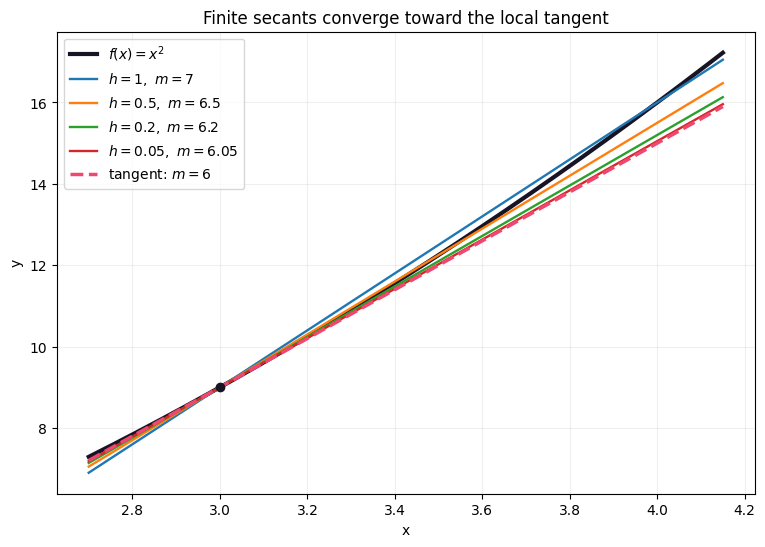

In [2]:
xs = np.linspace(2.7, 4.15, 500)
hs = [1.0, 0.5, 0.2, 0.05]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(xs, f(xs), color='#171426', linewidth=3, label=r'$f(x)=x^2$')
for h in hs:
    slope = (f(x0 + h) - f(x0)) / h
    ax.plot(xs, f(x0) + slope * (xs - x0), linewidth=1.7, label=fr'$h={h:g},\ m={slope:g}$')

ax.plot(xs, f(x0) + df(x0) * (xs - x0), '--', color='#ef476f', linewidth=2.5, label=r'tangent: $m=6$')
ax.scatter([x0], [f(x0)], color='#171426', zorder=5)
ax.set(xlabel='x', ylabel='y', title='Finite secants converge toward the local tangent')
ax.grid(alpha=0.2)
ax.legend()
plt.show()

## Local-linearization error

For the quadratic, the exact error after removing the derivative's linear prediction is $E(h)=h^2$.

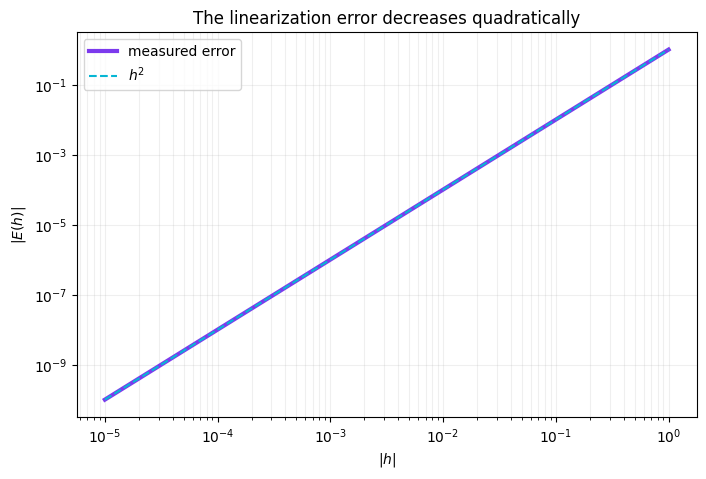

In [3]:
hs_error = np.logspace(-5, 0, 100)
exact_change = f(x0 + hs_error) - f(x0)
linear_change = df(x0) * hs_error
error = np.abs(exact_change - linear_change)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(hs_error, error, color='#7c3aed', linewidth=3, label='measured error')
ax.loglog(hs_error, hs_error**2, '--', color='#06b6d4', label=r'$h^2$')
ax.set(xlabel=r'$|h|$', ylabel=r'$|E(h)|$', title='The linearization error decreases quadratically')
ax.grid(which='both', alpha=0.2)
ax.legend()
plt.show()

## Riemann sums accumulating the derivative

Left and right sums bracket the exact value $\int_3^4 2x\,dx=7$.

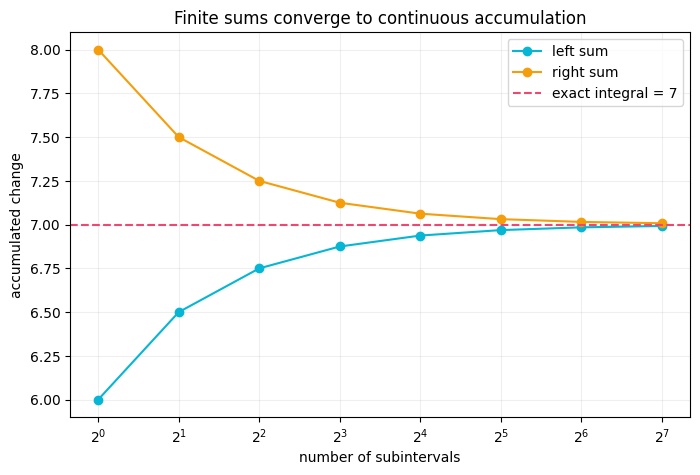

[(1, 6.0, 8.0),
 (2, 6.5, 7.5),
 (4, 6.75, 7.25),
 (8, 6.875, 7.125),
 (16, 6.9375, 7.0625),
 (32, 6.96875, 7.03125),
 (64, 6.984375, 7.015625),
 (128, 6.9921875, 7.0078125)]

In [ ]:
def riemann_sums(rate, a, b, n):
    dx = (b - a) / n
    left_x = a + np.arange(n) * dx
    right_x = left_x + dx
    return dx * rate(left_x).sum(), dx * rate(right_x).sum()

ns = np.array([1, 2, 4, 8, 16, 32, 64, 128])
pairs = np.array([riemann_sums(df, 3.0, 4.0, int(n)) for n in ns])
left, right = pairs[:, 0], pairs[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ns, left, 'o-', color='#06b6d4', label='left sum')
ax.plot(ns, right, 'o-', color='#f59e0b', label='right sum')
ax.axhline(7.0, color='#ef476f', linestyle='--', label='exact integral = 7')
ax.set_xscale('log', base=2)
ax.set(xlabel='number of subintervals', ylabel='accumulated change', title='Finite sums converge to continuous accumulation')
ax.grid(alpha=0.2)
ax.legend()
plt.show()

list(zip(ns.tolist(), left.tolist(), right.tolist()))

The final value is reconstructed by adding the accumulated derivative to the initial condition: $f(4)=f(3)+7=16$.